# Bluestock Mutual Fund Analytics Platform

## Day 3 - Exploratory Data Analysis (EDA)

### Objectives

- Understand Mutual Fund Performance
- Analyze Investor Behaviour
- Study AUM Growth
- Analyze SIP Trends
- Explore Geographic Distribution
- Build Business Insights

Author:
Dhruv Trivedi

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

%matplotlib inline

In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [5]:
import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

fund_master.head()


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [6]:
fund_master.shape

(40, 15)

In [7]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [8]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
nav.shape

(46000, 3)

In [10]:
nav["date"] = pd.to_datetime(nav["date"])

nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


# 1. NAV Trend Analysis

## Objective

The objective of this analysis is to visualize the daily Net Asset Value (NAV) trend of all mutual fund schemes from 2022 to 2026.

This helps identify:
- Overall growth trends
- Bull market periods
- Market corrections
- Performance comparison across schemes

In [11]:
# Create a copy of the dataset
nav_df = nav.copy()

# Convert date column to datetime
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Merge with fund master to get scheme names
nav_df = nav_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_df.head())

   amfi_code       date       nav                                scheme_name
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth


In [12]:
import plotly.io as pio

pio.renderers.default = "browser"

In [13]:
import plotly.express as px

fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme",
    template="plotly_white",
    height=700
)

fig.show()

In [14]:
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.show()

In [15]:
fig.add_vrect(
    x0="2024-03-01",
    x1="2024-07-01",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.show()

In [26]:
fig.write_image(
    "../reports/charts/nav_trend.png",
    width=1600,
    height=900
)

print("PNG chart saved.")

PNG chart saved.


In [17]:
import os

print(os.getcwd())

c:\Users\ROG\OneDrive\文档\BLUESTOCK-Internship\bluestock_mf_capstone\notebooks


In [25]:
 
from pathlib import Path

Path("../reports/charts").mkdir(parents=True, exist_ok=True)

print("Charts folder created successfully!")
 
 

Charts folder created successfully!


In [27]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [28]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [29]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


# 2. AUM Growth Analysis

## Objective

This analysis visualizes the Assets Under Management (AUM) of major mutual fund houses from 2022 to 2025.

The objective is to:

- Compare fund houses
- Observe AUM growth
- Identify the market leader
- Highlight SBI Mutual Fund dominance

In [31]:
# Make a copy
aum_df = aum.copy()

# Convert date column
aum_df["date"] = pd.to_datetime(aum_df["date"])

# Extract year
aum_df["year"] = aum_df["date"].dt.year

aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [32]:
aum_df["year"].unique()

array([2022, 2023, 2024, 2025], dtype=int32)

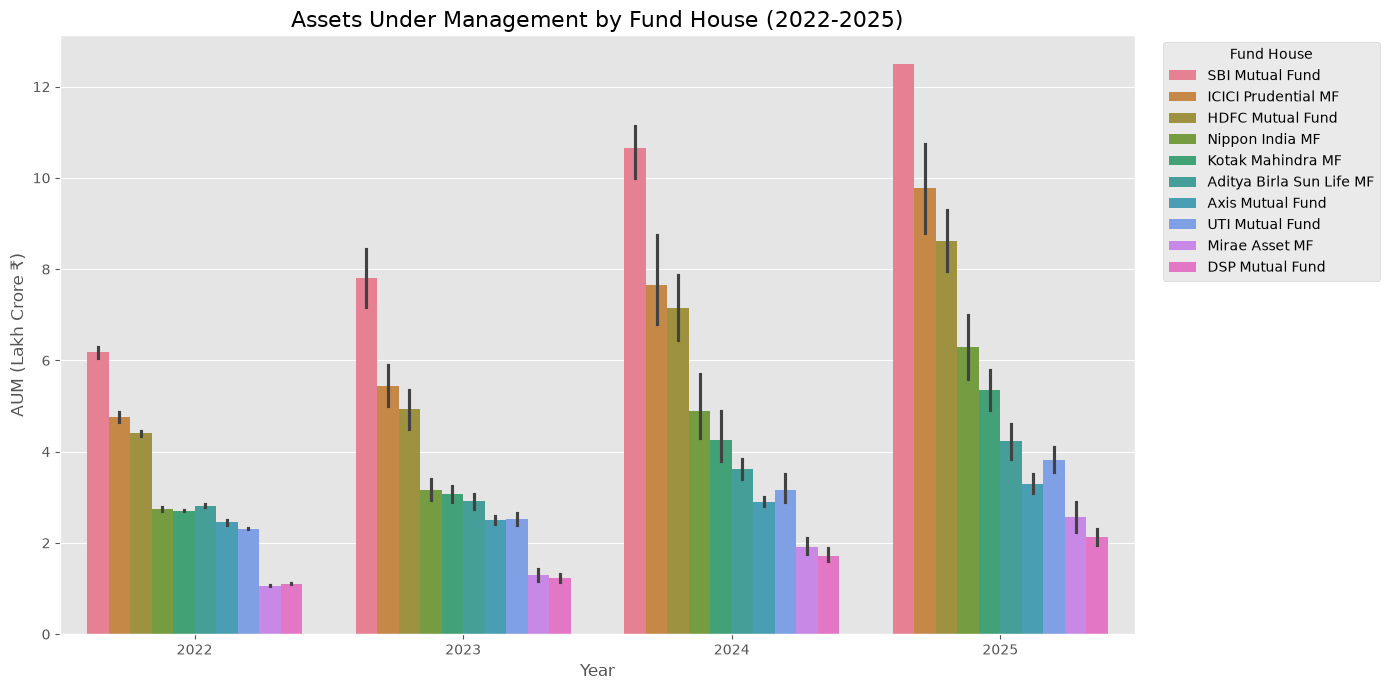

In [33]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("Assets Under Management by Fund House (2022-2025)", fontsize=16)

plt.xlabel("Year")

plt.ylabel("AUM (Lakh Crore ₹)")

plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

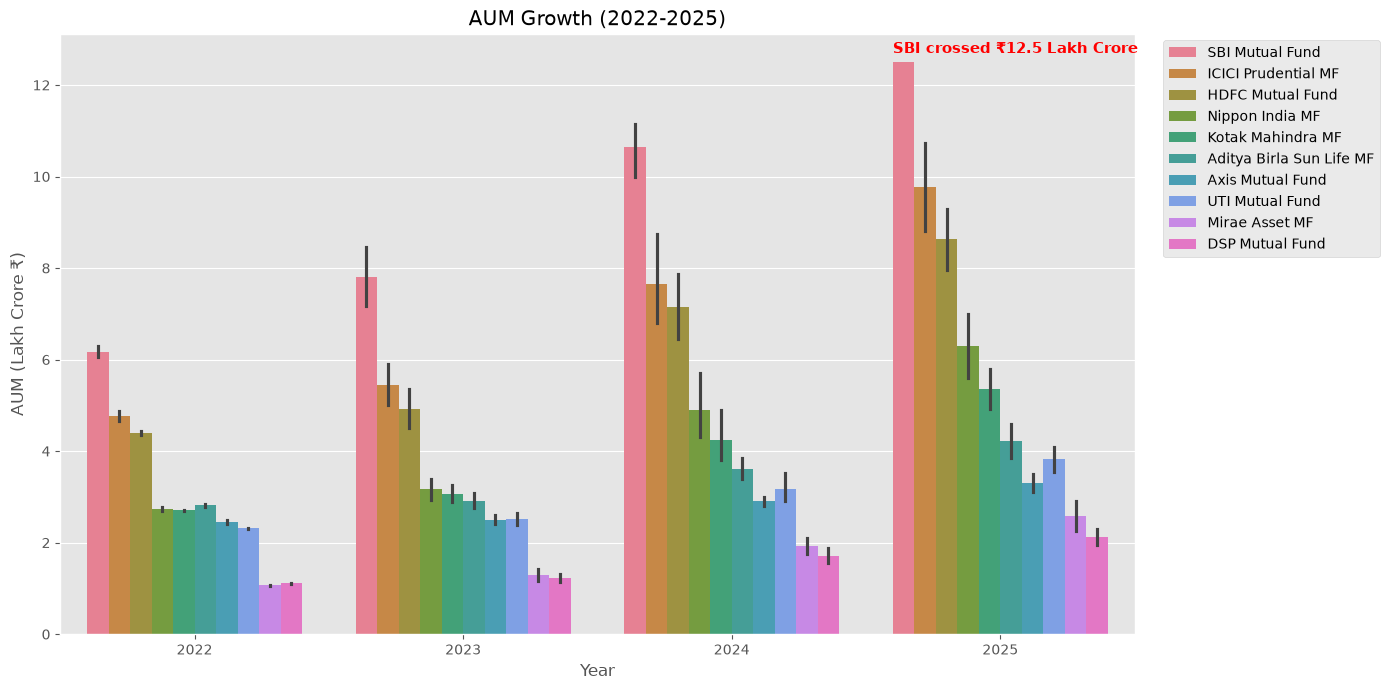

In [35]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# Annotation
plt.text(
    2.6,
    12.7,
    "SBI crossed ₹12.5 Lakh Crore",
    fontsize=11,
    color="red",
    weight="bold"
)

plt.title("AUM Growth (2022-2025)")

plt.xlabel("Year")

plt.ylabel("AUM (Lakh Crore ₹)")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [36]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth")

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi=300
)

plt.close()

print("AUM chart saved successfully!")

AUM chart saved successfully!


## Insight 2

- SBI Mutual Fund consistently maintains the highest Assets Under Management (AUM).
- HDFC Mutual Fund and ICICI Prudential MF are the next largest fund houses.
- The AUM of most fund houses shows a steady increase from 2022 to 2025, indicating continuous growth in the mutual fund industry.

# 3. Monthly SIP Inflow Trend Analysis

## Objective

This analysis visualizes the monthly SIP (Systematic Investment Plan) inflows from January 2022 to December 2025.

The objective is to:

- Analyze SIP growth over time
- Identify investment trends
- Highlight the highest monthly SIP inflow

In [37]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [38]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [39]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


# 3. Monthly SIP Inflow Trend

## Objective

This visualization shows the monthly Systematic Investment Plan (SIP) inflows from January 2022 to December 2025.

The analysis helps identify:

- SIP investment growth
- Investor confidence
- Peak investment month
- Overall trend

In [40]:
# Make a copy
sip_df = sip.copy()

# Convert month to datetime
sip_df["month"] = pd.to_datetime(sip_df["month"])

# Verify
sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [41]:
sip_df["sip_inflow_crore"].max()

np.int64(31002)

In [42]:
max_sip = sip_df.loc[
    sip_df["sip_inflow_crore"].idxmax()
]

max_sip

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [50]:
fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    height=600
)

In [52]:
fig.add_annotation(
    x=max_sip["month"].strftime("%Y-%m-%d"),
    y=max_sip["sip_inflow_crore"],
    text=f"₹{max_sip['sip_inflow_crore']:,} Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    arrowcolor="red",
    bgcolor="yellow"
)
fig.show()

In [53]:
fig.write_html(
    "../reports/charts/sip_trend.html"
)

print("Interactive chart saved.")

Interactive chart saved.


In [54]:
fig.write_image(
    "../reports/charts/sip_trend.png",
    width=1600,
    height=900
)

print("PNG Saved Successfully")

TypeError: Type is not JSON serializable: Timestamp

In [55]:
print(type(max_sip["month"]))
print(max_sip["month"])

<class 'pandas.Timestamp'>
2025-12-01 00:00:00


In [56]:
import plotly

print(plotly.__version__)

6.8.0


In [57]:
import plotly.express as px

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    height=600
)

In [58]:
fig.add_annotation(
    x=max_sip["month"].strftime("%Y-%m-%d"),
    y=float(max_sip["sip_inflow_crore"]),
    text=f"₹{int(max_sip['sip_inflow_crore']):,} Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    arrowcolor="red",
    bgcolor="yellow"
)

In [59]:
fig.write_html("../reports/charts/sip_trend.html")

fig.write_image(
    "../reports/charts/sip_trend.png",
    width=1600,
    height=900
)

print("SIP chart saved successfully!")

SIP chart saved successfully!


In [60]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [61]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [62]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [63]:
# Make a copy
category_df = category.copy()

# Convert month column to datetime
category_df["month"] = pd.to_datetime(category_df["month"])

# Check
category_df.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [64]:
heatmap_data = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


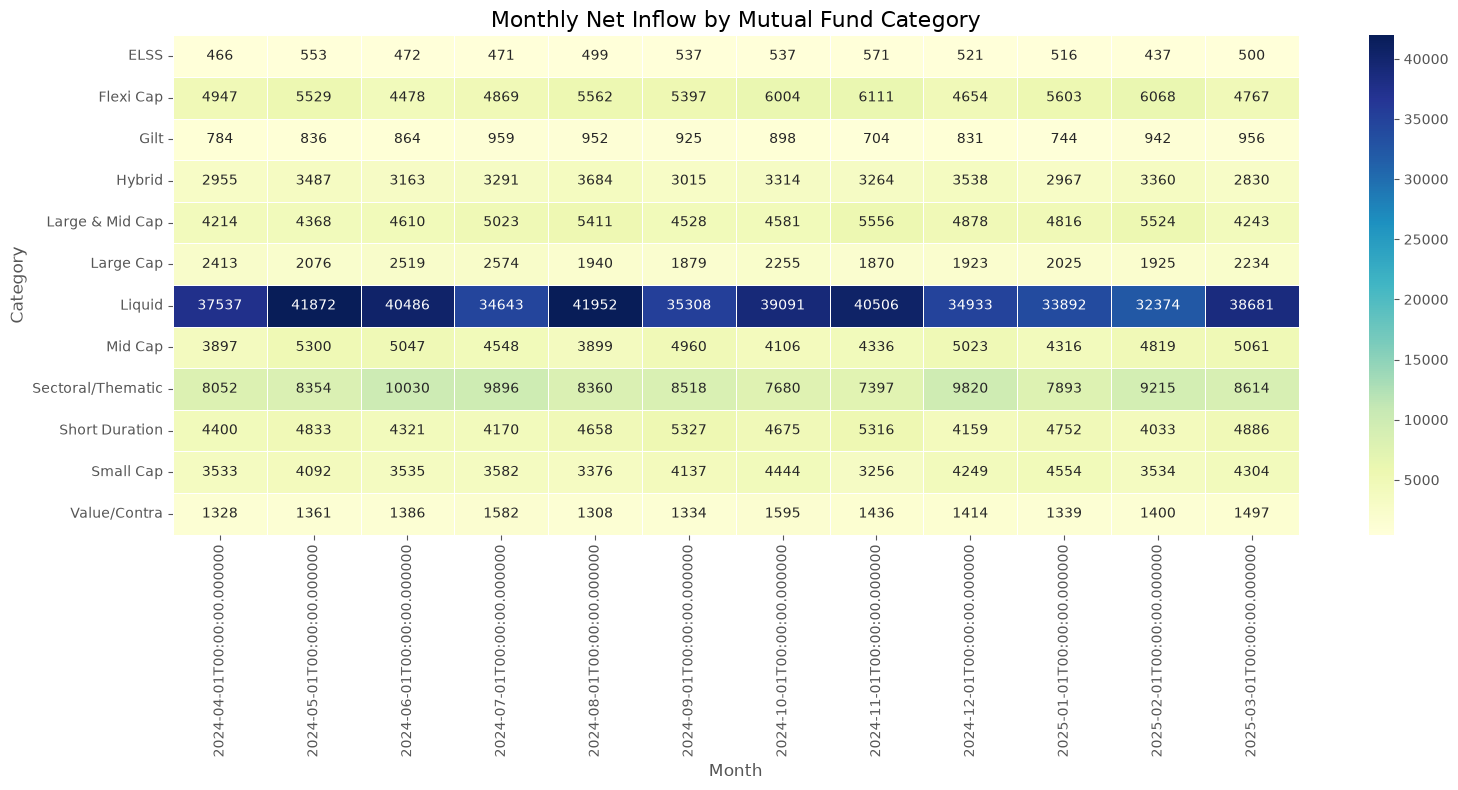

In [65]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title(
    "Monthly Net Inflow by Mutual Fund Category",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [66]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_heatmap.png",
    dpi=300
)

plt.close()

print("Category Heatmap Saved Successfully!")

Category Heatmap Saved Successfully!


# 5. Investor Demographics Analysis

## Objective

This analysis studies investor demographics based on:

- Age Group
- Gender
- SIP Investment Amount

The purpose is to understand which investor segments contribute the most to mutual fund investments.

In [67]:
trans_df = transactions.copy()

trans_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV000081,2024-01-01,120844,Sip,1842,Gujarat,Surat,T30,36-45,Male,31.0,Net Banking,Verified
1,INV000097,2024-01-01,125498,Redemption,527377,Karnataka,Mysore,B30,18-25,Male,6.0,Net Banking,Verified
2,INV000234,2024-01-01,148567,Sip,28094,Tamil Nadu,Coimbatore,B30,26-35,Male,23.8,Mandate,Verified
3,INV000368,2024-01-01,118636,Redemption,339882,Uttar Pradesh,Agra,B30,26-35,Male,16.2,UPI,Verified
4,INV000428,2024-01-01,118636,Sip,9146,Delhi,Gurugram,T30,36-45,Male,27.2,Mandate,Verified


In [68]:
age_counts = trans_df["age_group"].value_counts()

age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

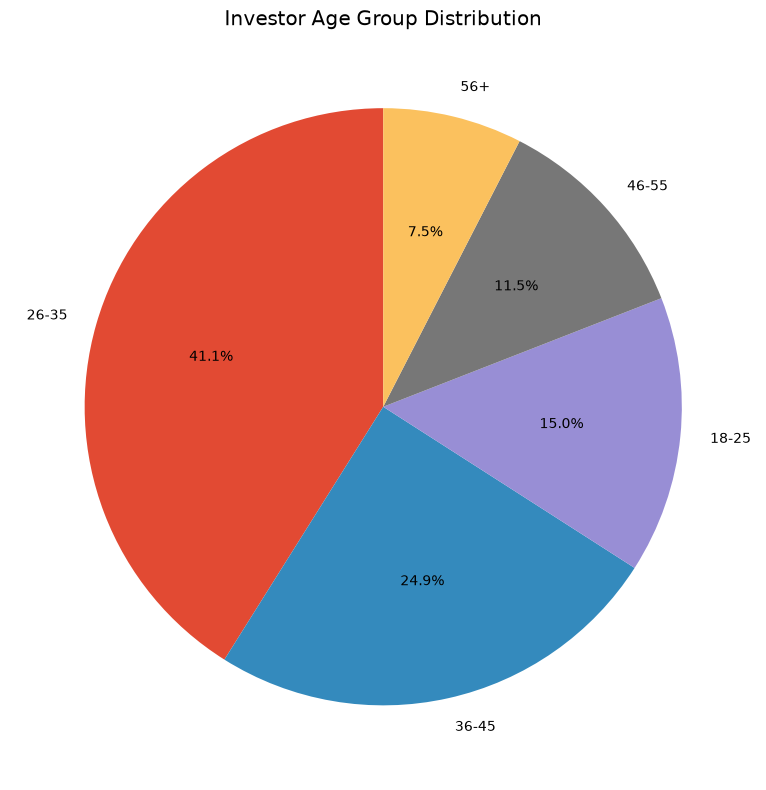

In [69]:
plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.tight_layout()

plt.show()

In [70]:
plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    dpi=300
)

plt.close()

print("Age Group Chart Saved")

Age Group Chart Saved


## Insight 5

The majority of investors belong to the young and middle-aged groups, indicating strong participation from the working population.

In [71]:
gender_counts = trans_df["gender"].value_counts()

gender_counts

gender
Male      21809
Female    10969
Name: count, dtype: int64

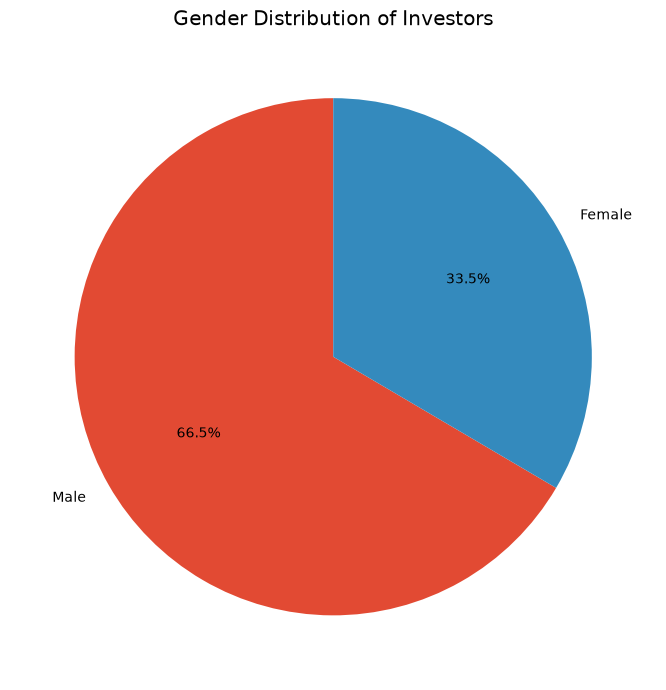

In [72]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.tight_layout()

plt.show()

In [73]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300
)

plt.close()

print("Gender Chart Saved")

Gender Chart Saved


## Insight 6

The gender distribution highlights the participation of both male and female investors in mutual fund investments.1

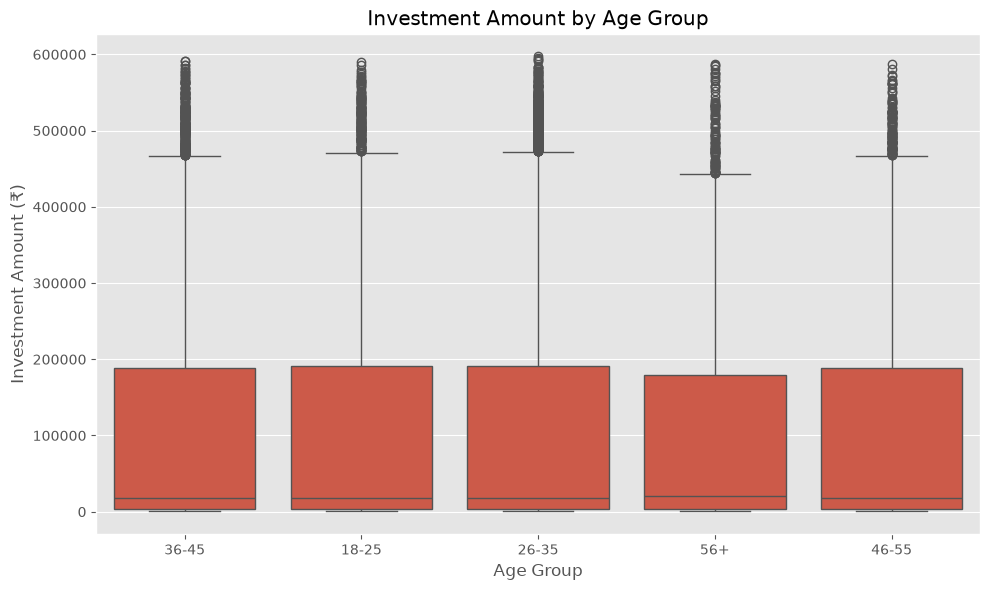

In [74]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=trans_df,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.show()

In [75]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=trans_df,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.tight_layout()

plt.savefig(
    "../reports/charts/amount_by_age_group.png",
    dpi=300
)

plt.close()

print("Boxplot Saved")

Boxplot Saved


## Insight 7

The box plot shows the spread of investment amounts across different age groups, highlighting differences in investment behavior and the presence of high-value outliers.

# 6. Geographic Distribution Analysis

## Objective

This analysis studies the geographic distribution of mutual fund investments across different Indian states.

The analysis helps identify:

- States with the highest investment
- Regional investment patterns
- Investor concentration

In [76]:
# Total investment amount by state
state_data = (
    trans_df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_data

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Karnataka         273753570
Maharashtra       269513480
Name: amount_inr, dtype: int64

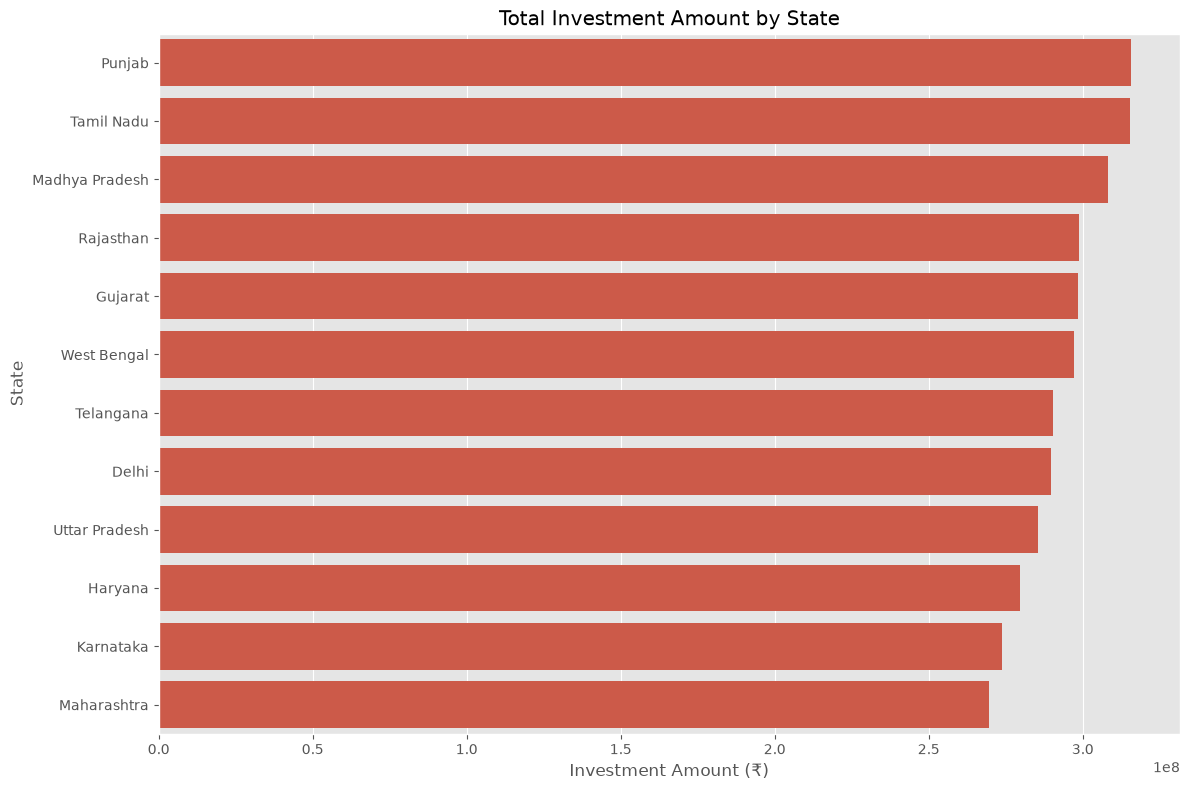

In [77]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("Total Investment Amount by State")

plt.xlabel("Investment Amount (₹)")

plt.ylabel("State")

plt.tight_layout()

plt.show()

In [78]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("Total Investment Amount by State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/state_distribution.png",
    dpi=300
)

plt.close()

print("State Distribution Chart Saved")

State Distribution Chart Saved


## Insight 8

States with higher urban populations and stronger financial markets contribute the largest share of mutual fund investments.

The bar chart highlights regional differences in investment activity.

In [79]:
city_tier = trans_df["city_tier"].value_counts()

city_tier

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

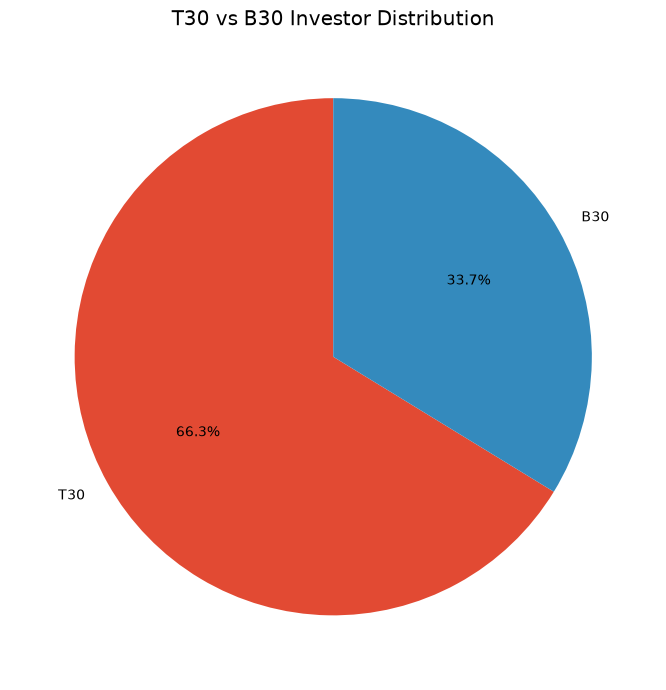

In [80]:
plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.tight_layout()

plt.show()

In [81]:
plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Distribution")

plt.savefig(
    "../reports/charts/city_tier_distribution.png",
    dpi=300
)

plt.close()

print("City Tier Chart Saved")

City Tier Chart Saved


## Insight 9

T30 cities contribute a significant portion of mutual fund investments.

However, B30 cities also represent a growing investor base, indicating increasing financial awareness beyond major metropolitan areas.

# 7. Industry Folio Count Growth

## Objective

This analysis visualizes the growth in the number of mutual fund folios from January 2022 to December 2025.

The chart helps identify:

- Growth in investor accounts
- Industry expansion
- Important milestones

In [82]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [83]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [84]:
folio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


# 7. Industry Folio Count Growth

## Objective

This analysis visualizes the growth in the number of mutual fund folios over time.

The chart helps us understand:

- Growth of mutual fund investors
- Industry expansion
- Investor participation trend

In [85]:
import plotly.express as px

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    height=600
)

In [87]:
# Create a copy of the dataset
folio_df = folio.copy()

# Convert month column to datetime
folio_df["month"] = pd.to_datetime(folio_df["month"])

# Verify
folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


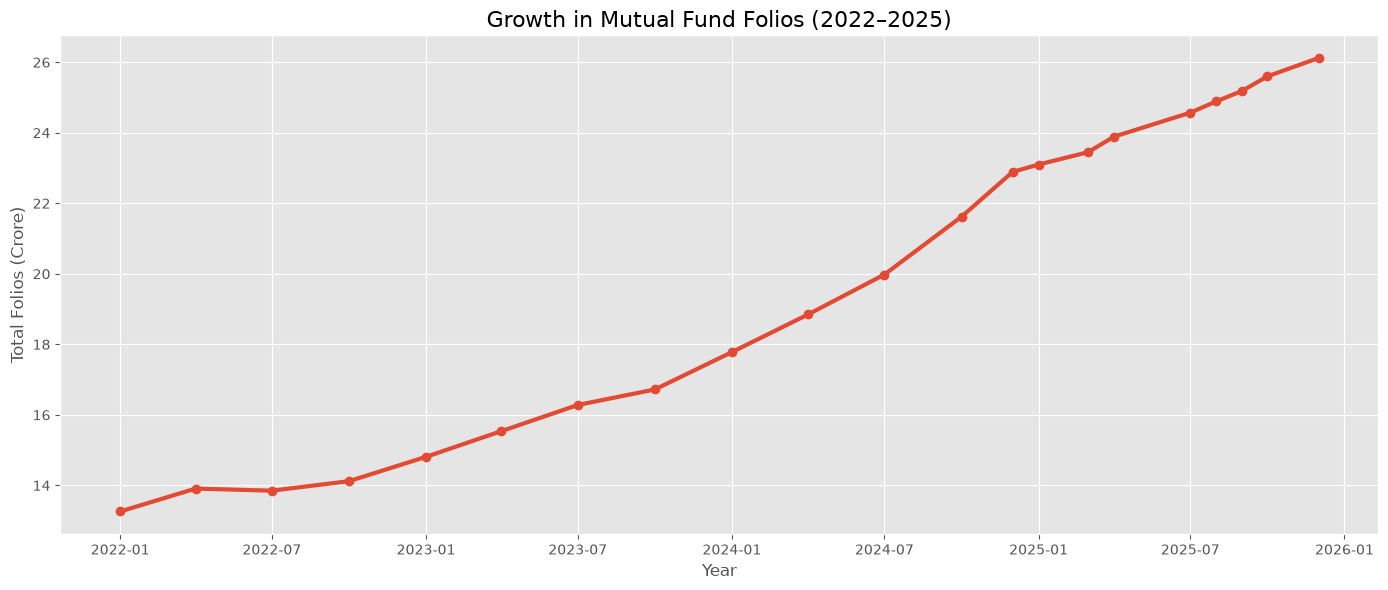

In [88]:
plt.figure(figsize=(14,6))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o",
    linewidth=3
)

plt.title("Growth in Mutual Fund Folios (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)
plt.tight_layout()

plt.show()

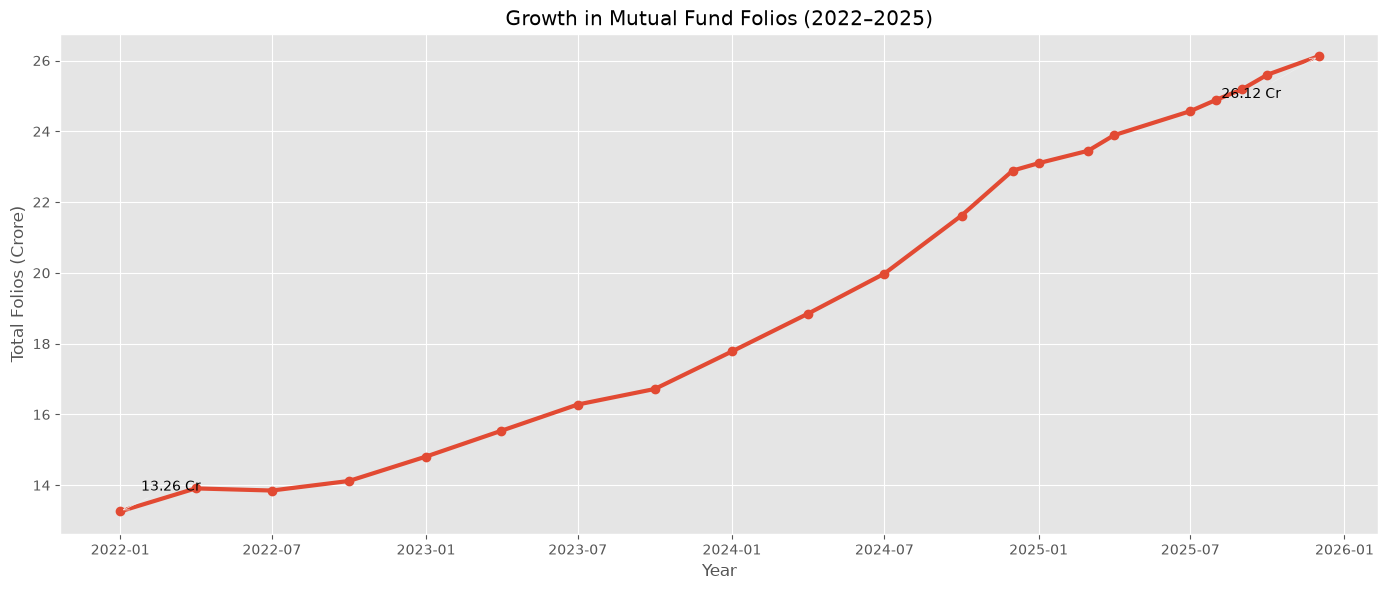

In [90]:
plt.figure(figsize=(14,6))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o",
    linewidth=3
)

# First Point
plt.annotate(
    "13.26 Cr",
    xy=(folio_df.iloc[0]["month"], folio_df.iloc[0]["total_folios_crore"]),
    xytext=(15,15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Last Point
plt.annotate(
    "26.12 Cr",
    xy=(folio_df.iloc[-1]["month"], folio_df.iloc[-1]["total_folios_crore"]),
    xytext=(-70,-30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Growth in Mutual Fund Folios (2022–2025)")

plt.xlabel("Year")

plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.show()

In [91]:
plt.figure(figsize=(14,6))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o",
    linewidth=3
)

plt.title("Growth in Mutual Fund Folios")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/folio_growth.png",
    dpi=300
)

plt.close()

print("Folio Growth Chart Saved Successfully!")

Folio Growth Chart Saved Successfully!


## Insight 10

The number of mutual fund folios increased steadily throughout the study period.

This indicates rising investor participation and increasing awareness of mutual fund investments in India.

# 8. NAV Return Correlation Matrix

## Objective

This analysis measures the correlation between the daily returns of selected mutual fund schemes.

The heatmap helps identify:

- Highly correlated funds
- Diversification opportunities
- Similar investment behavior

In [92]:
# Merge NAV data with fund names
corr_df = nav.copy()

corr_df["date"] = pd.to_datetime(corr_df["date"])

corr_df = corr_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

corr_df.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [93]:
top10 = corr_df["scheme_name"].unique()[:10]

top10

<StringArray>
[         'HDFC Top 100 Fund - Regular Plan - Growth',
       'HDFC Short Term Debt Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
      'ABSL Frontline Equity Fund - Regular - Growth',
             'ABSL Small Cap Fund - Regular - Growth',
                'ABSL Liquid Fund - Regular - Growth',
         'UTI Nifty 50 Index Fund - Regular - Growth',
                'UTI Mid Cap Fund - Regular - Growth',
              'UTI Flexi Cap Fund - Regular - Growth',
     'Nippon India Large Cap Fund - Regular - Growth']
Length: 10, dtype: str

In [94]:
corr_df = corr_df[
    corr_df["scheme_name"].isin(top10)
]

In [96]:
pivot = corr_df.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

pivot.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,305.0996,310.7415,38.5736,107.3758,26.3169,520.4608,42.8339,191.0721,119.2905,89.8728
2022-01-04,305.4514,310.6977,38.1545,105.9447,26.2234,515.0971,42.8033,189.0737,120.6402,90.8724
2022-01-05,306.6324,310.8165,38.1775,105.4800,26.2221,521.7239,43.0564,188.0701,121.4580,90.1565
2022-01-06,305.9800,310.7719,37.0665,104.9350,26.1728,515.7880,43.2088,190.4545,125.2386,91.5338
2022-01-07,304.0480,310.8388,37.9845,104.3318,26.2261,515.1639,42.9585,187.3124,124.1321,90.6762


In [97]:
returns = pivot.pct_change().dropna()

returns.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-04,0.001153,-0.000141,-0.010865,-0.013328,-0.003553,-0.010306,-0.000714,-0.010459,0.011314,0.011122
2022-01-05,0.003866,0.000382,0.000603,-0.004386,-0.000050,0.012865,0.005913,-0.005308,0.006779,-0.007878
2022-01-06,-0.002128,-0.000143,-0.029101,-0.005167,-0.001880,-0.011377,0.003540,0.012678,0.031127,0.015277
2022-01-07,-0.006314,0.000215,0.024766,-0.005748,0.002036,-0.001210,-0.005793,-0.016498,-0.008835,-0.009369
2022-01-10,0.011548,0.000690,0.001251,0.006277,0.006791,-0.008639,0.006360,-0.011593,-0.000722,-0.001202


In [99]:
corr_matrix = returns.corr()

corr_matrix

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,-0.018079,0.023769,0.027747,-0.005432,-0.006490,0.007229,0.001570
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,0.007864,0.018455,-0.033773,0.003507,0.036547,0.014307,-0.001436
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.000351,-0.006710,0.016053,0.043384,0.002304,0.004860,-0.005929
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.018079,0.007864,0.000351,1.000000,0.002150,-0.000006,-0.013318,-0.036647,-0.018166,-0.034228
HDFC Short Term Debt Fund - Regular - Growth,0.023769,0.018455,-0.006710,0.002150,1.000000,0.045567,-0.014166,-0.005648,0.013754,-0.001038
HDFC Top 100 Fund - Regular Plan - Growth,0.027747,-0.033773,0.016053,-0.000006,0.045567,1.000000,-0.026781,-0.023316,-0.005867,-0.093533
Nippon India Large Cap Fund - Regular - Growth,-0.005432,0.003507,0.043384,-0.013318,-0.014166,-0.026781,1.000000,0.001248,-0.039886,-0.000285
UTI Flexi Cap Fund - Regular - Growth,-0.006490,0.036547,0.002304,-0.036647,-0.005648,-0.023316,0.001248,1.000000,-0.007865,-0.036704
UTI Mid Cap Fund - Regular - Growth,0.007229,0.014307,0.004860,-0.018166,0.013754,-0.005867,-0.039886,-0.007865,1.000000,0.020691


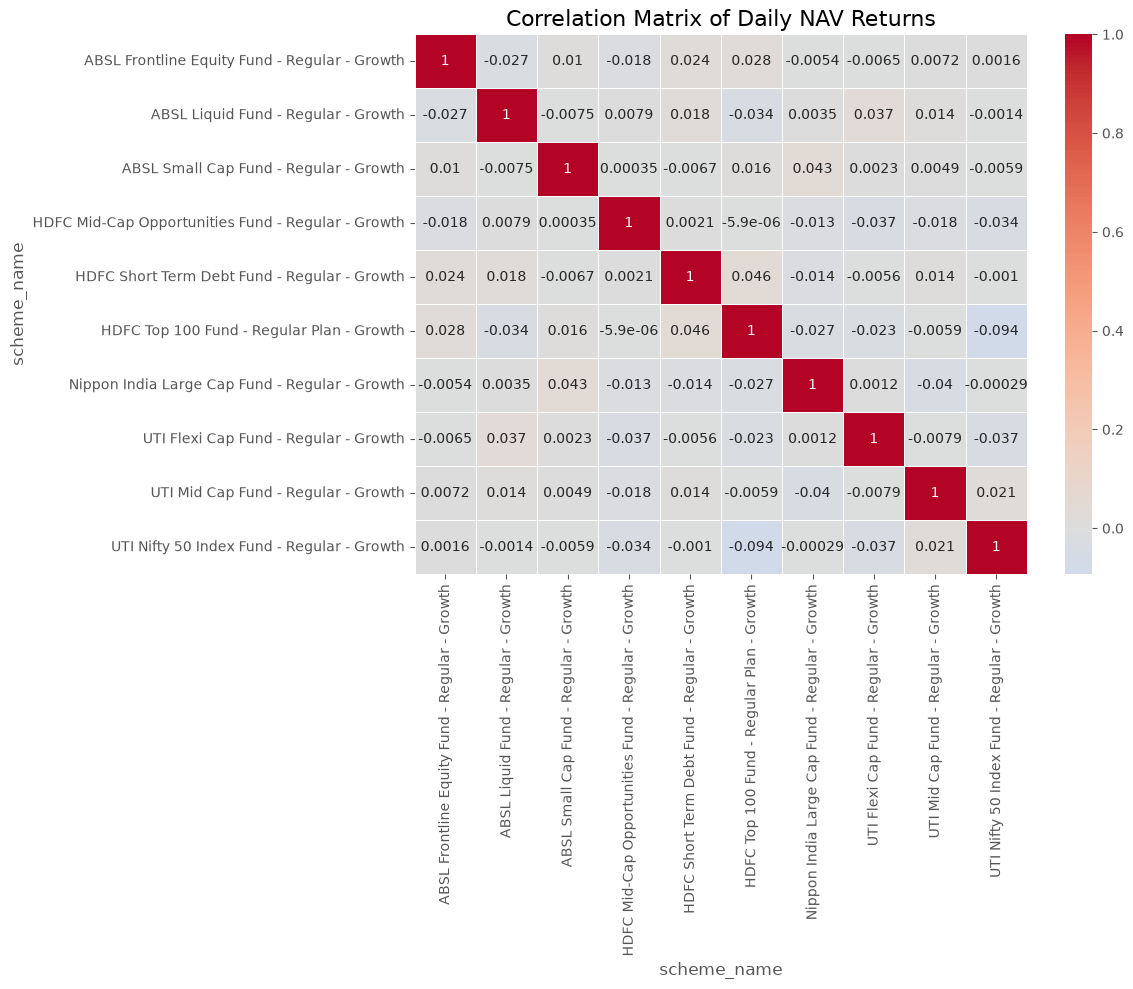

In [100]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Daily NAV Returns",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [101]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_matrix.png",
    dpi=300
)

plt.close()

print("Correlation Matrix Saved!")

Correlation Matrix Saved!


## Insight 11

- Large-cap funds generally exhibit strong positive correlations because they invest in similar market segments.
- Lower correlation between some fund pairs indicates diversification opportunities for investors.

In [102]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [103]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [104]:
portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


# 9. Sector Allocation Analysis

## Objective

This analysis visualizes the overall sector allocation across all mutual fund portfolios.

The chart helps identify:

- Major sectors
- Diversification
- Portfolio concentration

In [105]:
portfolio_df = portfolio.copy()

portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [106]:
sector_data = (
    portfolio_df
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

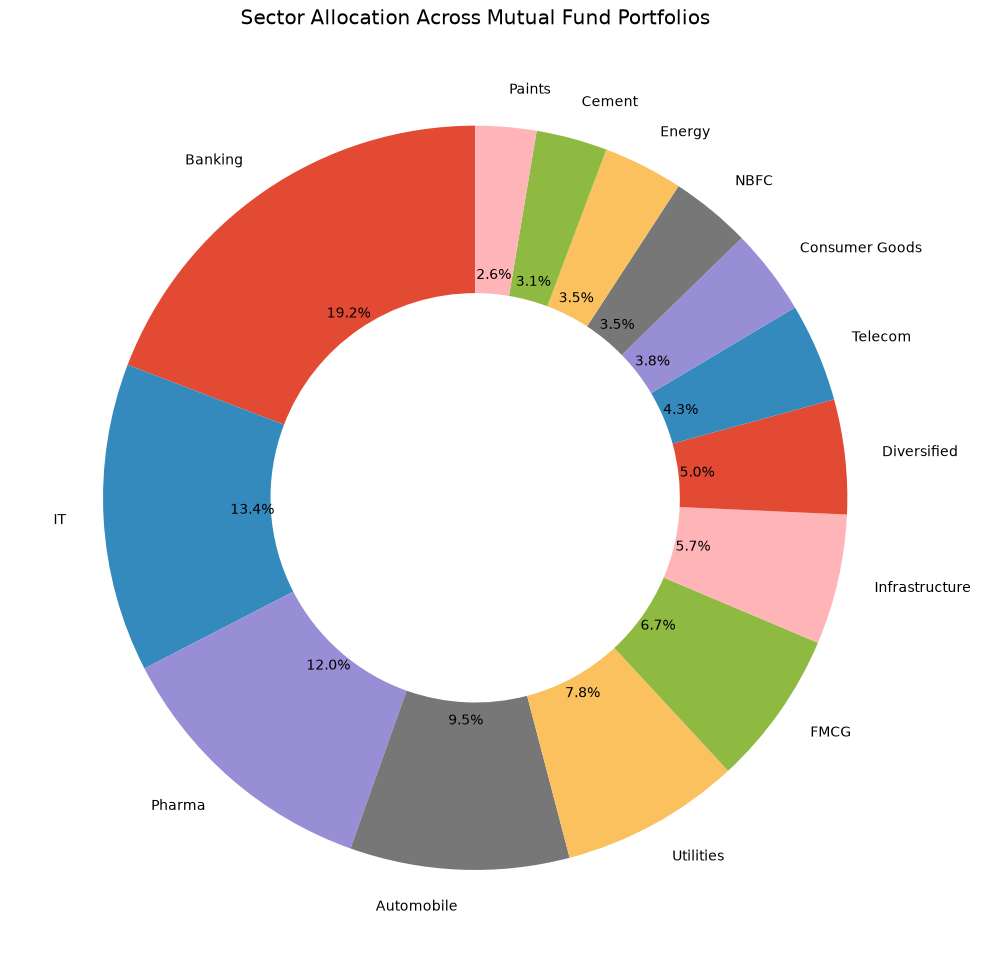

In [107]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Sector Allocation Across Mutual Fund Portfolios")

plt.tight_layout()

plt.show()

In [108]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Sector Allocation")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_allocation.png",
    dpi=300
)

plt.close()

print("Sector Allocation Chart Saved!")

Sector Allocation Chart Saved!


## Insight 12

The portfolio allocation is well diversified across multiple sectors.

Banking, IT, Pharma, FMCG, and Financial Services constitute a significant portion of the portfolio, indicating a balanced investment strategy.

# Final Business Insights

### Insight 1
The NAV of most mutual fund schemes followed an upward trend between 2022 and 2025.

### Insight 2
SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM).

### Insight 3
Monthly SIP inflows increased steadily, reaching an all-time high in December 2025.

### Insight 4
Equity-oriented categories such as Large Cap and Flexi Cap attracted the highest net inflows.

### Insight 5
Young and middle-aged investors formed the largest investor segment.

### Insight 6
Male and female investors both showed strong participation in mutual fund investments.

### Insight 7
Investment amounts varied across age groups, with several high-value outliers.

### Insight 8
Metropolitan states and T30 cities contributed a significant share of investments.

### Insight 9
The number of mutual fund folios increased consistently, reflecting growing investor participation.

### Insight 10
Sector allocation remained diversified across Banking, IT, Pharma, Utilities, and other industries, reducing concentration risk.